In [1]:
import os
from xspec import *
import xspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal
from scipy import optimize, stats
from iminuit import Minuit
from scipy.stats import chi2 as chi2_scipy


Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt
Xset.parallel.steppar = 10 # number of threads for steppar


# GOAL: to fit spectra in a window around the line. Use XSpec to fit

I only use 1 power-law+ gaussians. The goal is to check if this works for E>2 keV

Here I load the data 

In [2]:
AllData.clear()
path="/home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80/"
#filespectrum=path+"srctoolout_120_SourceSpec_00001.fits"
#fileRMF=path+"srctoolout_120_RMF_00001.fits"
#fileARF=path+"srctoolout_120_ARF_00001.fits"
filespectrumTM1=path+"srctoolout_120_SourceSpec_00001.fits"
fileRMFTM1=path+"srctoolout_120_RMF_00001.fits"
fileARFTM1=path+"srctoolout_120_ARF_00001.fits"
fileIBLineTM1="/home/jortecal/GitHub/eRosita/IBLines/LinesTM1.txt"
#
filespectrumTM2=path+"srctoolout_220_SourceSpec_00001.fits"
fileRMFTM2=path+"srctoolout_220_RMF_00001.fits"
fileARFTM2=path+"srctoolout_220_ARF_00001.fits"
fileIBLineTM2="/home/jortecal/GitHub/eRosita/IBLines/LinesTM2.txt"
#
filespectrumTM3=path+"srctoolout_320_SourceSpec_00001.fits"
fileRMFTM3=path+"srctoolout_320_RMF_00001.fits"
fileARFTM3=path+"srctoolout_320_ARF_00001.fits"
fileIBLineTM3="/home/jortecal/GitHub/eRosita/IBLines/LinesTM3.txt"
#
filespectrumTM4=path+"srctoolout_420_SourceSpec_00001.fits"
fileRMFTM4=path+"srctoolout_420_RMF_00001.fits"
fileARFTM4=path+"srctoolout_420_ARF_00001.fits"
fileIBLineTM4="/home/jortecal/GitHub/eRosita/IBLines/LinesTM4.txt"
#
filespectrumTM5=path+"srctoolout_520_SourceSpec_00001.fits"
fileRMFTM5=path+"srctoolout_520_RMF_00001.fits"
fileARFTM5=path+"srctoolout_520_ARF_00001.fits"
fileIBLineTM5="/home/jortecal/GitHub/eRosita/IBLines/LinesTM5.txt"
#
filespectrumTM6=path+"srctoolout_620_SourceSpec_00001.fits"
fileRMFTM6=path+"srctoolout_620_RMF_00001.fits"
fileARFTM6=path+"srctoolout_620_ARF_00001.fits"
fileIBLineTM6="/home/jortecal/GitHub/eRosita/IBLines/LinesTM6.txt"
#
filespectrumTM7=path+"srctoolout_720_SourceSpec_00001.fits"
fileRMFTM7=path+"srctoolout_720_RMF_00001.fits"
fileARFTM7=path+"srctoolout_720_ARF_00001.fits"
fileIBLineTM7="/home/jortecal/GitHub/eRosita/IBLines/LinesTM7.txt"
#
#Put here the TM you want to use 
#
telescope = "TM1" 

# Define telescope file mappings
telescope_files = {
    "TM1": (filespectrumTM1, fileRMFTM1, fileARFTM1, fileIBLineTM1),
    "TM2": (filespectrumTM2, fileRMFTM2, fileARFTM2, fileIBLineTM2),
    "TM3": (filespectrumTM3, fileRMFTM3, fileARFTM3, fileIBLineTM3),
    "TM4": (filespectrumTM4, fileRMFTM4, fileARFTM4, fileIBLineTM4),
    "TM5": (filespectrumTM5, fileRMFTM5, fileARFTM5, fileIBLineTM5),
    "TM6": (filespectrumTM6, fileRMFTM6, fileARFTM6, fileIBLineTM6),
    "TM7": (filespectrumTM7, fileRMFTM7, fileARFTM7, fileIBLineTM7),
    "ALL": ([filespectrumTM1, filespectrumTM2, filespectrumTM3, filespectrumTM4, filespectrumTM5, filespectrumTM6, filespectrumTM7],
            [fileRMFTM1, fileRMFTM2, fileRMFTM3, fileRMFTM4, fileRMFTM5, fileRMFTM6, fileRMFTM7],
            [fileARFTM1, fileARFTM2, fileARFTM3, fileARFTM4, fileARFTM5, fileARFTM6, fileARFTM7],
            [fileIBLineTM1, fileIBLineTM2, fileIBLineTM3, fileIBLineTM4, fileIBLineTM5, fileIBLineTM6, fileIBLineTM7]),
    "ALL_CLEAN": ([filespectrumTM1, filespectrumTM2, filespectrumTM3, filespectrumTM4, filespectrumTM6],
    [fileRMFTM1, fileRMFTM2, fileRMFTM3, fileRMFTM4, fileRMFTM6],
    [fileARFTM1, fileARFTM2, fileARFTM3, fileARFTM4, fileARFTM6],
    [fileIBLineTM1, fileIBLineTM2, fileIBLineTM3, fileIBLineTM4, fileIBLineTM6])
}

# Set the file arrays based on telescope selection
if telescope in telescope_files:
    if telescope == "ALL":
        vfilespectrum, vfileRMF, vfileARF, vfileIBLine = telescope_files[telescope]
    else:
        spectrum_file, rmf_file, arf_file, ibline_file = telescope_files[telescope]
        vfilespectrum = [spectrum_file]
        vfileRMF = [rmf_file]
        vfileARF = [arf_file]
        vfileIBLine = [ibline_file]
    print(f"Using telescope: {telescope}")
    print(f"Number of telescopes: {len(vfilespectrum)}")
else:
    print(f"Error: Unknown telescope '{telescope}'. Valid options: TM1, TM2, TM3, TM4, TM5, TM6, TM7, ALL_CLEAN")
    sys.exit(1)
# vfilespectrum = [filespectrumTM4]
# vfileRMF = [fileRMFTM4]
# vfileARF = [fileARFTM4]
#
#LOAD DATA
#

#
AllData.clear()
for plot_grp in range (0,len(vfilespectrum)):
    #print("plot_grp ",plot_grp)
    Spectrum(vfilespectrum[plot_grp])
    AllData(plot_grp+1).multiresponse[0] = vfileRMF[plot_grp]
    AllData(plot_grp+1).multiresponse[0].arf = vfileARF[plot_grp]
    AllData(plot_grp+1).multiresponse[1] = vfileRMF[plot_grp] # RMF only for src2

AllData.show()

Using telescope: TM1
Number of telescopes: 1

 response file  read skipped

1 spectrum  in use
 
Spectral Data File: /home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80/srctoolout_120_SourceSpec_00001.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.101e+00 +/- 1.747e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: eROSITA Instrument: TM1  Channel Type: PI
  Exposure Time: 3.608e+05 sec
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Response successfully loaded.
Arf successfully loaded.
Response successfully loaded.

1 file 1 spectrum 
Spectrum 1  Spectral Data File: /home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80/srctoolout_120_SourceSpec_00001.fits
Net count rate (cts/s) for Spectrum:1  1.101e+00 +/- 1.747e-03
 Assigned to Data Group 1 and Plot Group 1
  Notic

Error: cannot read response file srctoolout_120_RMF_00001.fits



  Exposure Time: 3.608e+05 sec
 Using fit statistic: chi
 Using Response (RMF) File            /home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80/srctoolout_120_RMF_00001.fits for Source 1
 Using Auxiliary Response (ARF) File  /home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80/srctoolout_120_ARF_00001.fits
 Using Response (RMF) File            /home/jortecal/GitHub/eRosita/LMC5DegEv/srctoolout_000_SourceProducts_00001_5deg_rebin80/srctoolout_120_RMF_00001.fits for Source 2



NOW LOAD the Sigma of EROSITA. At the moment I take the FWHM from https://erosita.mpe.mpg.de/edr/eROSITATechnical/calibration.html
Computing \sigma=FWHM/2.355 I find that \sigma ranges from [33,72] eV and E/sigma = [34,139] for E ranging from 1 to 10 keV. 
This is >> sigmav = c/v = 1360 for v=220 km/s.
Larger than intrinsic/Doppler width of astro lines???

In [3]:
data = np.loadtxt("/home/jortecal/GitHub/eRosita/3MLFits/Energy_width.txt",delimiter=",")
vE = data[:,0]
vFWHM = data[:,1]*1e-3 #keV
vsigma = vFWHM/(2.355)

Fix the energy of the DM line and select data

In [4]:
# I do not consider eROSITA data outside this range
Eallmin = 0.3
Eallmax = 9.

Eline = 1.687 #6.266

sigma = np.interp(Eline,vE,vsigma)
print("Eline ",Eline," sigma ",sigma)
Emin= Eline - 5*sigma
Emax= Eline + 5*sigma
if(Emin<Eallmin):
    Emin=Eallmin
if(Emax>Eallmax):
    Emax=Eallmax
# Emin= 1.0
# Emax= 3.0
print("Emin ",Emin," Emax ",Emax)
str_range = "**-"+str(round(Emin, 4))+",,"+str(round(Emax, 4))+"-**"
print(str_range)
AllData.ignore(str_range)


Plot.commands = ()
Plot.addCommand("area")
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
# Compute number of E bins, assumig it is the same for all TM
NEbins = len(np.asarray(Plot.x(1)))
print("NEbins ",NEbins)
venergies = np.zeros((len(vfilespectrum), NEbins))
vedeltas = np.zeros((len(vfilespectrum), NEbins))
vrates = np.zeros((len(vfilespectrum), NEbins))
verrors = np.zeros((len(vfilespectrum), NEbins))
for i in range (0,len(vfilespectrum)):
    plot_grp = i + 1 # so that it starts with 1
    energiesTMi = np.asarray(Plot.x(plot_grp))
    edeltasTMi = np.asarray(Plot.xErr(plot_grp))
    ratesTMi = np.asarray(Plot.y(plot_grp))
    errorsTMi = np.asarray(Plot.yErr(plot_grp))
    venergies[i] = energiesTMi 
    vedeltas[i] = edeltasTMi 
    vrates[i] = ratesTMi 
    verrors[i] = errorsTMi 
    print("***************")
    print("Selected values ",np.min(energiesTMi)," ",np.max(energiesTMi)," Nbins ",len(energiesTMi))
    print("***************")
    channelmin = AllData(plot_grp).noticed[0] -1
    channelmax = AllData(plot_grp).noticed[-1]
    #print("channelmin/max ",channelmin," ",channelmax)
    #
    SpectrumOpen = fits.open(vfilespectrum[plot_grp-1])['SPECTRUM']
    counts_TMi = SpectrumOpen.data.field('COUNTS')#
    channel_TMi = SpectrumOpen.data.field('CHANNEL')#
    exposure_TMi=fits.getval(vfilespectrum[plot_grp-1],"exposure", ext=1)
    RMFOpen = fits.open(vfileRMF[plot_grp-1])['EBOUNDS']
    Emin_data_TMi = RMFOpen.data.field('E_MIN')#keV
    Emax_data_TMi = RMFOpen.data.field('E_MAX')#keV
    Eave_data_TMi = (Emin_data_TMi+Emax_data_TMi)/2.
    DeltaE_data_TMi = Emax_data_TMi-Emin_data_TMi
    DeltaE_ana_TMi = DeltaE_data_TMi[channelmin:channelmax]
    Eave_ana_TMi = Eave_data_TMi[channelmin:channelmax]
    channel_ana_TMi = channel_TMi[channelmin:channelmax]
    counts_ana_TMi = counts_TMi[channelmin:channelmax]
    print("Min Max counts ",np.min(counts_ana_TMi)," ",np.max(counts_ana_TMi))


Eline  1.687  sigma  0.034236889238964084
Emin  1.5158155538051796  Emax  1.8581844461948205
**-1.5158,,1.8582-**
Plot command list is now empty
NEbins  40
***************
Selected values  1.5220332145690918   1.8504182696342468  Nbins  40
***************
   218 channels (1-218) ignored in spectrum #     1
   766 channels (259-1024) ignored in spectrum #     1

 Syntax: Ajust ON|OFF wlist
Min Max counts  340   482


In [5]:
print("sigma ",sigma)
print("DeltaE ",vedeltas[0]*2)
print("Sigma/DeltaE ",sigma/(vedeltas[0]*2))

sigma  0.034236889238964084
DeltaE  [0.00814152 0.00815618 0.00817049 0.00818515 0.00819945 0.00821412
 0.00822842 0.00824273 0.00825703 0.00827169 0.00828588 0.00830019
 0.00831449 0.00832915 0.00834298 0.00835752 0.00837159 0.0083859
 0.00840032 0.00841427 0.00842857 0.00844264 0.00845695 0.00847077
 0.0084852  0.00849915 0.00851345 0.00852716 0.00854123 0.00854957
 0.0085752  0.00857723 0.00859725 0.0086112  0.00862503 0.00863898
 0.00865269 0.00866687 0.00868046 0.00869429]
Sigma/DeltaE  [4.20522202 4.1976621  4.19031271 4.18280625 4.17550875 4.16805519
 4.16080903 4.15358801 4.14639202 4.13904195 4.13195567 4.12483437
 4.11773758 4.11048866 4.10367563 4.09653453 4.08965117 4.08267482
 4.0756644  4.06890858 4.06200276 4.05523486 4.04837533 4.04176649
 4.03489573 4.02827428 4.02150559 4.01504023 4.00842779 4.00451544
 3.99254654 3.99160322 3.98230484 3.97585474 3.96948036 3.9630717
 3.95679272 3.95031626 3.94413177 3.93785862]


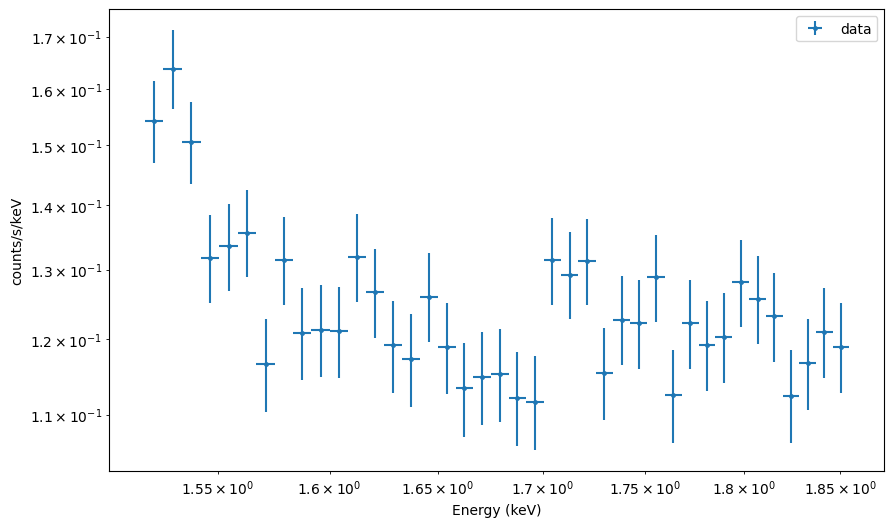

In [6]:
#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
for i in range (0,len(vfilespectrum)):
    ax.errorbar(venergies[i], vrates[i], xerr=vedeltas[i],yerr=verrors[i],fmt='.',markersize='5',label='data')
#ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Now I consider the Astro and Internal Background lines falling into the energy range +- 7 sigma. At the end I define arrays containing the position of the lines and the min and max values inside which they can fluctuate in the fit


In [7]:
EminL = Eline - 7*sigma
EmaxL = Eline + 7*sigma
if(EminL<Eallmin):
    EminL = Eallmin
if(EmaxL>Eallmax):
    EmaxL = Eallmax

if isinstance(vfileIBLine, list):
    ib_file = vfileIBLine[0]
else:
    ib_file = vfileIBLine

# Load IB lines
data = np.loadtxt(ib_file, skiprows=0)
IBenergy = data[:,0]
# IBenergymin = data[:,2]
# IBenergymax = data[:,5]
IBenergymin = data[:,0]-0.025
IBenergymax = data[:,0]+0.025
data = np.loadtxt("/home/jortecal/GitHub/eRosita/3MLFits/MarcoFitsMay/AstroLines.txt",skiprows=0)
Aenergy = data[:,0]
Aenergymin = data[:,1]
Aenergymax = data[:,2]
#print(Aenergy," ",IBenergy)
#print(len(Aenergy)," ",len(IBenergy))
IBidx = np.where( (IBenergy > EminL ) & (IBenergy < EmaxL ) )
Aidx = np.where( (Aenergy > EminL ) & (Aenergy < EmaxL ) )
IBLine = IBenergy[IBidx]
IBLinemin = IBenergymin[IBidx]
IBLinemax = IBenergymax[IBidx]



ALine = Aenergy[Aidx]
#ALinemin = Aenergymin[Aidx]
#ALinemax = Aenergymax[Aidx]
# SET HERE VARIATION OF ASTRO LINE
AstroEl = 0.005;
ALinemin = ALine - AstroEl
ALinemax = ALine + AstroEl


IBn = len(IBLine)
An = len(ALine)
#
# For this model avoid Astro lines
#
IBALine = IBLine.copy()
IBALinemin = IBLinemin.copy()
IBALinemax = IBLinemax.copy()
IBAn = IBn
idx = np.argsort(IBALine)
IBALine = IBALine[idx]
IBALinemin = IBALinemin[idx]
IBALinemax = IBALinemax[idx]
print("Total lines ",IBAn," IB ",IBn," A ",An)
print(IBALine)
print(IBALinemin," ",IBALinemax)

Total lines  1  IB  1  A  0
[1.47994]
[1.45494]   [1.50494]


FUNCTIONS TO SET LINES TO ZERO AND FIX THEM OR TO FREE THEM

In [8]:
# CLASS TO DEFINE A FUNCTION TO EVALUATE THE TS specified in fit GIVEN A xspec Model model
# with paramers value params, name (gaussian_3, powerlaw,...) params_name and target (norm, LineE,...) params_target

class MTmodel:
    def __init__(self, model, params_name, params_target, fit):
        self.model = model
        self.params_name = params_name
        self.params_target = params_target
        self.fit = fit

        # Precompile fast setters for just the main value (index 0 of .values)
        # Finds the XSPEC parameter object via getattr(model, name).attr for example: model.powerlaw.PhoIndex
        # Calls _make_fast_setter(param_obj)
        # Stores the resulting function in a list
        self._param_fast_setters = [
            self._make_fast_setter(getattr(getattr(model, name), attr))
            for name, attr in zip(params_name, params_target)
        ]

        # Also keep full parameter objects for set_values_all
        self._param_objects = [
            getattr(getattr(model, name), attr)
            for name, attr in zip(params_name, params_target)
        ]
    
    #It creates a closure that:
    #remembers the XSPEC parameter object
    #updates its value only (fast update)
    def _make_fast_setter(self, param_obj):
        def setter(value, param_obj=param_obj):
            #param_obj.values[0] = value
            # scalar assignment → only sets values[0]
            param_obj.values = value
        return setter

    #set value of parameters
    #if params = [1.2, 3.4, 6.7], this calls: setter_0(1.2) setter_1(3.4) setter_2(6.7)
    def set_values(self, params):
        for setter, value in zip(self._param_fast_setters, params):
            setter(float(value))  # direct, fast assignment

    #set value of parameters including upper/lower limits
    def set_values_all(self, params, lowers, uppers, keyfits):
        """
        Set parameter values and limits.
        keyfits[i] == True  → parameter is free
        keyfits[i] == False → parameter is frozen
        """
        for i, param in enumerate(self._param_objects):
            a = float(params[i])
            b = float(lowers[i])
            c = float(uppers[i])
            step = float(np.abs(1e-2*a))
            # for frozen parameters
            if not keyfits[i]:
                # --- Frozen parameter: safe assignment (no step, identical limits)
                param.values = [a, step, b, b, c, c]
                param.frozen = True
                continue

            param.values = [a, step, b, b, c, c]
            param.frozen = False

    # evaluate TS given paramaters params
    def evaluate_folded(self, params):
        self.set_values(params)
        return self.fit.statistic

    # set a given params_name, params_target to keyfits, i.e. True/False. Relevant for fit with xSpec
    # Careful: my logic is True means is in the fit therefore corresponds to .frozen = False
    def set_frozen(self, keyfits):
        """
        Freeze or unfreeze parameters based on keyfits.
        keyfits[i] == True  → parameter is free (frozen = False)
        keyfits[i] == False → parameter is frozen (frozen = True)
        """
        if len(keyfits) != len(self.params_name):
            raise ValueError("keyfits must be the same length as params_name and params_target")

        for param, keep_free in zip(self._param_objects, keyfits):
            param.frozen = not keep_free  # Invert: True means not frozen

    # return the value of the parameters    
    def get_values(self):
        """Return current values (i.e., param.values[0]) as numpy array."""
        return np.array([param.values[0] for param in self._param_objects])

In [9]:
# Functions working on dictionary

# Given a dictionary model_dic,
# extract all entries as numpy arrays
def Extract_array_dic(model_dic):
    params = []
    lowers = []
    uppers = []
    keyfits = []
    params_name = []
    params_target = []
    for top_key, sub_models in model_dic.items():
        # Skip non-model entries like _structure
        if not isinstance(sub_models, dict):
            continue
        for sub_key, parameters in sub_models.items():
            for paramtarget, param_info in parameters.items():
                params.append(param_info["value"])
                lowers.append(param_info["lower"])
                uppers.append(param_info["upper"])
                keyfits.append(param_info["keyfit"])
                params_name.append(sub_key)     # second-level key (e.g., powerlaw_2)
                params_target.append(paramtarget)     # third-level key (e.g., PhoIndex)

    # Convert everything to NumPy arrays
    params = np.array(params)
    lowers = np.array(lowers)
    uppers = np.array(uppers)
    params_name = np.array(params_name)
    params_target = np.array(params_target)
    keyfits = np.array(keyfits)
    return (params,lowers,uppers,params_name,params_target,keyfits)

In [10]:
# Functions working on numpy arrays

# input arrays defining all the parameters of the model
# output: arrays of parameters entering in the fit (keyfits is True)
def paramfit(params, lowers, uppers , params_name, params_target, keyfits):
    # Create a mask for where keyfits is True
    mask = keyfits == True
    #print(keyfits)
    #print(mask)
    # Apply the mask
    params_out = params[mask]
    lowers_out = lowers[mask]
    uppers_out = uppers[mask]
    params_name_out = params_name[mask]
    params_target_out = params_target[mask]
    keyfits_out = keyfits[mask]
    bounds_out = np.column_stack((lowers_out, uppers_out))
    #print("Values:", params)
    #print("Lowers:", lowers)
    #print("Uppers:", uppers)
    #print("Keyfits:", keyfits)
    #print("Submodel keys:", params_name)
    #print("Param keys:", params_target)
    return (params_out, bounds_out, params_name_out, params_target_out, keyfits_out)

# Select element of params_name, params_target associated to params_name, target_key
# and for that change keyfits to keyfits_value
def change_keyfits(params_name, params_target, keyfits, name_key, target_key, keyfits_value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask) #True==1
    #print(idx[0]," ",name_key[idx[0]])
    keyfits[idx[0]] = keyfits_value

# For params associated to name_key, target_key change the value to key_value 
def change_param_value(params, params_name, params_target, name_key, target_key, value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    params[idx[0]] = value

# Return params associated to name_key, target_key
def return_param_value(params, params_name, params_target, name_key, target_key):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    return params[idx[0]]

# Print parameters
def printparam(params, lowers, uppers , params_name, params_target, keyfits):
    for i in range(0,len(params_name)):
        print(params_name[i]," ",params_target[i]," ", params[i]," ", lowers[i]," ", uppers[i]," ", keyfits[i])

Normalization factor (can be useful to define limits of the parameters)

In [11]:
# COMPUTE norm of the line to hit data
# to have an idea of a sensible normalization
# For simplicity choose TM1
arf1test = fits.open(fileARFTM1)['SPECRESP']
arf1ELOW = arf1test.data.field('ENERG_LO')#keV
arf1EHI = arf1test.data.field('ENERG_HI')#keV
arf1Aeff = arf1test.data.field('SPECRESP')#cm2
arf1E = (arf1ELOW + arf1EHI)/2.
Aefftest = np.interp(Eline, arf1E, arf1Aeff)
Ratetest = np.interp(Eline, venergies[0], vrates[0])
normlDMhdata = Ratetest/Aefftest # counts/keV/s/cm2
print("normlDMhdata [counts/keV/s/cm2]",normlDMhdata)
# normlDMhdata2 is the correct normalization to set norm of DM gaussian line to a reasonable value! 
# It has the same units of norm of Gaussian
# See nAPEC_Alll.ipynb
normlDMhdata2 = normlDMhdata*np.sqrt(2*np.pi)*sigma # counts/s/cm2
print("normlDMhdata2 [counts/s/cm2]",normlDMhdata2)


normlDMhdata [counts/keV/s/cm2] 0.13568296590031534
normlDMhdata2 [counts/s/cm2] 0.01164419742742954


Create the dictionary of the model

In [12]:
# #This is a model based on TBabsorption and APEC phenomenological models
# def pdic(value, lower, upper, key):
#     return {"value": value, "lower": lower, "upper": upper, "keyfit": key}


# normline_start= normlDMhdata2*0.01 #*0.01
# normline_lower = 0.0
# normline_upper = normlDMhdata2*500
# sigmaDM = Eline*50/3e5 #1e-4 TAKE INTO ACCOUNT THAT LMC VELOCITY IS 50 km/s
# sigma_astrolines = 1e-4
# #
# #
# #The foreground Milkyway nH value is cm (https://www.swift.ac.uk/analysis/nhtot/index.php)
# startnH = 6.3e-2 #1e22 cm-2
# #uppernH = startnH*100. #*100
# #lowernH = startnH*0.01 #*0.01
# # do not allow too crazy values
# uppernH = .7#
# lowernH = 0.001#
# # apec https://cxc.cfa.harvard.edu/sherpa/ahelp/xsapec.html
# startapec = 2.5e-2 #from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb)
# upperapec = 1
# lowerapec = 1e-4
# startT = 0.23 #keV
# upperT = 8.0 # keV
# lowerT = 0.01
# startAb = 1.0 # from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb)
# upperAb = 5.0
# lowerAb = 0.01
# #power law
# startidx = 3 #1.4
# upperidx = 6.0
# loweridx = - 3.0
# #
# startpl = 0.01*normlDMhdata *np.pow(Eline,startidx)
# # startpl = 0.05
# upperpl = startpl*1000.0
# lowerpl = 0.0

# #
# # I always define DM to be the first gaussian. I set parameters to False (no in the fit)
# model_dic = {
#     "gaussian": {
#         "gaussian": {
#             "norm": pdic(normline_start, normline_lower, normline_upper, False),
#             "LineE": pdic(Eline, Eline, Eline, False),
#             "Sigma": pdic(sigmaDM, sigmaDM, sigmaDM, False)
#         }
#     },
#     "TBabs": {
#         "TBabs": {
#             "nH": pdic(startnH, lowernH, uppernH, True),
#         }
#     },
#     "apec": {
#         "apec": {
#             "kT": pdic(startT, lowerT, upperT, True),
#             "norm": pdic(startapec, lowerapec, upperapec, True),
#             "Abundanc": pdic(startAb, lowerAb, upperAb, False),
#             "Redshift": pdic(0, 0, 0, False)
#         }
#     },
#     "powerlaw": {
#         "powerlaw": {
#             "PhoIndex": pdic(startidx, loweridx, upperidx, True),
#             "norm": pdic(startpl, lowerpl, upperpl, True)
#         }
#     }
# }

# model_dic["_structure"] = f"TBabs * (apec + gaussian + powerlaw)"
    
# #ADD gaussian lines
# #
# # Count all second-level keys in the entire model_dic
# # print(model_dic.values())
# start_index_astrol = sum(
#     len(sub_models) for sub_models in model_dic.values()
#     if isinstance(sub_models, dict)
# )
# start_index_astrol = start_index_astrol + 1
# print("start_index_astrol ",start_index_astrol)

# model_dic_pb = {
    
#     "powerlaw": {
#         "powerlaw": {
#             "PhoIndex": pdic(startidx, loweridx, upperidx, True), # (value, lower, upper, key)
#             "norm" : pdic(startpl, lowerpl, upperpl, True)
#             }
#         },
#         "gaussian": {}  # 
#     }
# #
# # Start numbering from start_index_astrol to avoid conflict with "gaussian"
# for i in range(len(IBALine)):
#     if i == 0:
#         g_key = "gaussian"
#     else:
#         g_key = f"gaussian_{i+2}"  # XSPEC adds suffixes starting at _2
#     model_dic_pb["gaussian"][g_key] = {
#         "norm": pdic(normline_start, normline_lower, normline_upper, True),
#         "LineE": pdic(IBALine[i], IBALinemin[i], IBALinemax[i], True),
#         "Sigma": pdic(sigma_astrolines, sigma_astrolines, sigma_astrolines, False)
#     }


# print('Normline start ',normline_start,' lower ',normline_lower,' upper ',normline_upper)

In [13]:
#============================================================================
# PHYSICAL PARAMETER INITIALIZATION FOR LMC X-RAY SPECTRAL FITTING
#============================================================================
# LMC parameters: RA ~80.89°, Dec ~-69.75°, Distance ~50 kpc, Z ~ 0.3-0.5 Z☉
# Galactic nH from Swift/LAB surveys: 6.0-6.5 × 10²⁰ cm⁻²
#============================================================================

def pdic(value, lower, upper, key):
    return {"value": value, "lower": lower, "upper": upper, "keyfit": key}

smallnormlower = 1e-13 # if you want to avoid setting lower limit to zero
smallnorm = 1e-10 # if you want to avoid setting norm to zero


normline_start= normlDMhdata2*0.01 #*0.01
normline_lower = smallnormlower
normline_upper = normlDMhdata2*1000
sigmaDM = Eline*50/3e5 #1e-4
sigma_astrolines = 1e-4
#
#
#power law
startidx = 1.0 #1.4
upperidx = 4.5
loweridx = - 3.0
#
# This normalization should be resonable for PL folded through the ARF
startpl = 0.1*normlDMhdata *np.pow(Eline,startidx)
# startpl = 0.05
#upperpl = startpl*1000.0
upperpl = normlDMhdata *np.pow(Eline,upperidx)*100.
lowerpl = smallnormlower
print("startpl ",startpl," upperpl ",upperpl)
#TABS
#from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb)
#The foreground Milkyway nH value is cm (https://www.swift.ac.uk/analysis/nhtot/index.php)
# returns 0.3. IN eROSITA LMC paper they have 0.3-0.4 in sources and 8e-2 between SNR
# See also https://ui.adsabs.harvard.edu/abs/2011ApJ...728..159W/abstract (NO arXiv plot is wrong, open published version)
#, LMC is at −32.89, 280.46. I expect NH around few*1e-2
startnH = 6.3e-2 # 6.3e-2 1e22 cm-2 #0.4
# do not allow too crazy values
uppernH = 0.8 #
lowernH = 1.0e-2
#
# APEC https://cxc.cfa.harvard.edu/sherpa/ahelp/xsapec.html
#from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb)
startapec = 0.14 # from global fit
upperapec = 2.0
lowerapec = smallnormlower
startT = 0.23 #keV 0.23 0.87
upperT = 3.0 # keV 8.0
lowerT = 0.05
startAb = 1.0 # from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb)
upperAb = 1.0 #5.0
lowerAb = 1.0 #0.01
#
#
# I always define DM to be the first gaussian. I set parameters to False (no in the fit)
model_dic = {
    "TBabs": {
        "TBabs": {
            "nH": pdic(0.014504730943138755, lowernH, uppernH, False), # (value, lower, upper, key)
            }
        },
    "apec": {
        "apec": {
            "kT": pdic(24583332400464597, lowerT, upperT, False), # (value, lower, upper, key)
            "Abundanc" : pdic(startAb, lowerAb, upperAb, False),
            "Redshift" : pdic(0., 0., 0.0, False), #0., 0., 0.
            "norm" : pdic(1.991872044485489, lowerapec, upperapec, False)
            }
        },
    "powerlaw": {
        "powerlaw": {
            "PhoIndex": pdic(0, loweridx, upperidx, False), # (value, lower, upper, key)
            "norm" : pdic(1e-10, lowerpl, upperpl, False)
            }
        },
    "gaussian": {
        "gaussian": {
            "LineE" : pdic(Eline, Eline, Eline, False),
            "Sigma" : pdic(sigmaDM, sigmaDM, sigmaDM, False), #sigmaDM, sigmaDM, sigmaDM
            "norm": pdic(normline_start, normline_lower, normline_upper, False), # (value, lower, upper, key)
            }
        }
    }
# gaussian_components = [f"gaussian" for i in range(len(IBALine))]
# gaussian_sum = " + ".join(gaussian_components)
# if len(IBALine)>0:
#     model_dic["_structure"] = f"gaussian+ {gaussian_sum}" 
# else:
model_dic["_structure"] = f"tbabs*(apec + powerlaw + gaussian)"
    
#ADD gaussian lines
#
# Count all second-level keys in the entire model_dic
# print(model_dic.values())
start_index_astrol = sum(
    len(sub_models) for sub_models in model_dic.values()
    if isinstance(sub_models, dict)
)
start_index_astrol = start_index_astrol + 1
print("start_index_astrol ",start_index_astrol)

model_dic_pb = {
    
    "powerlaw": {
        "powerlaw": {
            "PhoIndex": pdic(-0.371323004057074, loweridx, upperidx, False), # (value, lower, upper, key)
            "norm" : pdic(0.0895498456161, lowerpl, upperpl, False)
            }
        },
        "gaussian": {}  # This is the DM line
    }
#
# Start numbering from start_index_astrol to avoid conflict with "gaussian"
for i in range(len(IBALine)):
    if i == 0:
        g_key = "gaussian"
    else:
        g_key = f"gaussian_{i+2}"  # XSPEC adds suffixes starting at _2
    model_dic_pb["gaussian"][g_key] = {
        "norm": pdic(0.003446429422432, normline_lower, normline_upper, False),
        "LineE": pdic(IBALine[i], IBALinemin[i], IBALinemax[i], False),
        "Sigma": pdic(sigma_astrolines, sigma_astrolines, sigma_astrolines, False)
    }


# print(f"✓ Initialized models for LMC (Eline = {Eline:.2f} keV)")
# print(f"  TBabs nH:    {startnH:.3f} [{lowernH:.3f}-{uppernH:.3f}] × 10²² cm⁻²")
# print(f"  APEC kT:     {startT:.2f} [{lowerT:.2f}-{upperT:.2f}] keV")
# print(f"  APEC Z:      {startAb:.2f} Z☉ (FROZEN)")
# print(f"  MW Γ:        {startidx_mw:.1f} [{loweridx_mw:.1f}-{upperidx_mw:.1f}]")
# print(f"  PB Γ:        {startidx_pb:.1f} [{loweridx_pb:.1f}-{upperidx_pb:.1f}]")
# print(f"  IB lines:    {len(IBALine)} gaussians")

# #============================================================================
# # POST-FIT VALIDATION (add after each Fit.perform())
# #============================================================================

# def validate_fit_results(model_mw, model_pb, fit_stat, fit_dof):
#     """Check for unphysical parameter values after fitting."""
#     warnings = []
    
#     # Check nH
#     nH = model_mw.TBabs.nH.values[0]
#     if nH < 0.04:
#         warnings.append(f"⚠️  nH = {nH:.3f} below expected Galactic value (0.063)")
#     if nH > 0.10:
#         warnings.append(f"⚠️  nH = {nH:.3f} suggests intrinsic LMC absorption")
    
#     # Check APEC kT
#     kT = model_mw.apec.kT.values[0]
#     if kT < 0.12:
#         warnings.append(f"⚠️  kT = {kT:.2f} keV too cold for X-ray emission")
#     if kT > 1.4:
#         warnings.append(f"⚠️  kT = {kT:.2f} keV suggests SNR/hot gas (consider 2nd APEC)")
    
#     # Check APEC norm (emission measure)
#     apec_norm = model_mw.apec.norm.values[0]
#     EM = apec_norm * 4 * np.pi * (50e3 * 3.086e18)**2 / 1e-14  # cm⁻³ for D=50kpc
#     if EM > 1e60:
#         warnings.append(f"⚠️  Emission measure {EM:.1e} cm⁻³ suspiciously high")
    
#     # Check photon indices
#     gamma_mw = model_mw.powerlaw.PhoIndex.values[0]
#     if gamma_mw < 1.0 or gamma_mw > 3.5:
#         warnings.append(f"⚠️  MW photon index Γ = {gamma_mw:.2f} outside typical range")
    
#     gamma_pb = model_pb.powerlaw.PhoIndex.values[0]
#     if gamma_pb < -0.5 or gamma_pb > 1.5:
#         warnings.append(f"⚠️  PB photon index Γ = {gamma_pb:.2f} unusual for instrumental bkg")
    
#     # Check fit quality
#     reduced_chi2 = fit_stat / fit_dof
#     if reduced_chi2 > 2.0:
#         warnings.append(f"⚠️  Poor fit: C-stat/dof = {reduced_chi2:.2f} (residuals present)")
    
#     return warnings

# USAGE (insert after Fit.perform()):
# warnings = validate_fit_results(m_mw, AllModels(1, "mpb"), Fit.statistic, Fit.dof)
# for w in warnings:
#     print(w)

startpl  0.0228897163473832  upperpl  142.73918079317937
start_index_astrol  5


In [14]:
print(model_dic)
print("******")
print(model_dic_pb)

{'TBabs': {'TBabs': {'nH': {'value': 0.014504730943138755, 'lower': 0.01, 'upper': 0.8, 'keyfit': False}}}, 'apec': {'apec': {'kT': {'value': 24583332400464597, 'lower': 0.05, 'upper': 3.0, 'keyfit': False}, 'Abundanc': {'value': 1.0, 'lower': 1.0, 'upper': 1.0, 'keyfit': False}, 'Redshift': {'value': 0.0, 'lower': 0.0, 'upper': 0.0, 'keyfit': False}, 'norm': {'value': 1.991872044485489, 'lower': 1e-13, 'upper': 2.0, 'keyfit': False}}}, 'powerlaw': {'powerlaw': {'PhoIndex': {'value': 0, 'lower': -3.0, 'upper': 4.5, 'keyfit': False}, 'norm': {'value': 1e-10, 'lower': 1e-13, 'upper': np.float64(142.73918079317937), 'keyfit': False}}}, 'gaussian': {'gaussian': {'LineE': {'value': 1.687, 'lower': 1.687, 'upper': 1.687, 'keyfit': False}, 'Sigma': {'value': 0.0002811666666666667, 'lower': 0.0002811666666666667, 'upper': 0.0002811666666666667, 'keyfit': False}, 'norm': {'value': np.float64(0.0001164419742742954), 'lower': 1e-13, 'upper': np.float64(11.64419742742954), 'keyfit': False}}}, '_st

Define the model

In [ ]:
if "_structure" in model_dic:
    finalM_xp = model_dic["_structure"]
else:
    baseM_parts = []
    for top_key, sub_models in model_dic.items():
        count = len(sub_models)
        baseM_parts.extend([top_key] * count)
    finalM_xp = '+'.join(baseM_parts)

print("mw ", finalM_xp)
AllModels.clear()
m_mw = Model(finalM_xp, "mw", 1)
#
#Add Particle bkg power law
#
# Build model string: one powerlaw + N gaussian components
n_gauss = len(model_dic_pb["gaussian"])
print("n_gauss ",n_gauss)
model_string_pb = "powerlaw"
if n_gauss > 0:
    model_string_pb += " + " + " + ".join(["gaussian"] * n_gauss)
print("mpb model string:", model_string_pb)
model_dic_pb["_structure"] = model_string_pb
AllModels += (model_string_pb, "mpb", 2)

#
print("MPB model components:", [name for name in dir(AllModels(1, "mpb")) if "gaussian" in name])

Xset.chatter = 0
Fit.statMethod = "cstat"
Fit.nIterations = 100000
#
# Extract the relevant info from the model dictionary
params, lowers, uppers, params_name, params_target, keyfits = Extract_array_dic(model_dic)
#
mymodel_mw = MTmodel(model=m_mw, params_name=params_name, params_target=params_target, fit=Fit)
#
# Extract the relevant info from the model dictionary of PB
params_pb, lowers_pb, uppers_pb, params_name_pb, params_target_pb, keyfits_pb = Extract_array_dic(model_dic_pb)
#
mymodel_pb = MTmodel(model=AllModels(1,"mpb"), params_name=params_name_pb, params_target=params_target_pb, fit=Fit)
#
#
# set the values including the upper and lower limits in Xspec
mymodel_mw.set_values_all(params, lowers, uppers, keyfits)
# set the free parameters in Xspec
mymodel_mw.set_frozen(keyfits)
#
mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb, keyfits_pb)
mymodel_pb.set_frozen(keyfits_pb)



#print("****************")
#printparam(params, lowers, uppers , params_name, params_target, keyfits)
#print("****************")
#print("****************")
#printparam(params_pb, lowers_pb, uppers_pb , params_name_pb, params_target_pb, keyfits_pb)
#print("****************")
#PrintModelXspec()
#print("****************")
#print("****************")



# %%
# If not already specified in initial dictionarys set DM to False and norm to 0
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)
change_param_value(params, params_name, params_target, "gaussian", "norm", smallnormlower)
#
# since you have changed norm and key(True/False), update XSpec
mymodel_mw.set_values_all(params, lowers, uppers,keyfits)
mymodel_mw.set_frozen(keyfits)
# %%
# %%
# Xset.chatter = 10
# AllModels.show()
# # Xset.chatter = 0


#

# Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics

# TS= 1e6
# for phoindex in np.arange(loweridx_pb, upperidx_pb, 1):
#     change_param_value(params_pb, params_name_pb, params_target_pb, "powerlaw", "PhoIndex", phoindex)
#     change_param_value(params_pb, params_name_pb, params_target_pb, "powerlaw", "norm", startpl_pb)
#     mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb)
#     mymodel_pb.set_frozen(keyfits_pb)

#     Fit.method = "migrad"
#     Fit.nIterations = 10000
#     Fit.criticalDelta = 1e-3
#     Fit.perform()

#     Fit.method = "leven"
#     Fit.nIterations = 10000
#     Fit.criticalDelta = 1e-4
#     Fit.perform()

#     Fit.method = "migrad"
#     Fit.nIterations = 10000
#     Fit.criticalDelta = 1e-5
#     Fit.perform()
#     params_initial = mymodel_pb.get_values()
#     params_name_initial = mymodel_pb.params_name
#     params_target_initial = mymodel_pb.params_target
#     if Fit.statistic < TS:
#         TS =  Fit.statistic
#         phoindex_initial = return_param_value(params_initial, params_name_initial, params_target_initial, "powerlaw", "PhoIndex")
#         norm_initial = return_param_value(params_initial, params_name_initial, params_target_initial, "powerlaw", "norm")

# change_param_value(params_pb, params_name_pb, params_target_pb, "powerlaw", "PhoIndex", phoindex_initial)
# change_param_value(params_pb, params_name_pb, params_target_pb, "powerlaw", "norm", norm_initial)

# mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb)
# mymodel_pb.set_frozen(keyfits_pb)
# Xset.chatter = 10
# AllModels.show()
# # Xset.chatter = 0
# # If not already specified in initial dictionarys set DM to False and norm to 0
# change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)
# change_param_value(params, params_name, params_target, "gaussian", "norm", 0.0)

# # since you have changed norm and key(True/False), update XSpec
# mymodel_mw.set_values_all(params, lowers, uppers)
# mymodel_mw.set_frozen(keyfits)


# # Select the parameters to Fit. You can check that DM is not present
# params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)
# print("Fitting parameters", params_target_fit)


mw  tbabs*(apec + powerlaw + gaussian)

Model mw:TBabs<1>(apec<2> + powerlaw<3> + gaussian<4>) Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
n_gauss  1
mpb model string: powerlaw + gaussian
MPB model components: ['gaussian']
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   apec       kT         keV      1.00000      +/-  0.0          
   3    2   apec       Abundanc            1.00000      frozen
   4    2   apec       Redshift            0.0          frozen
   5    2   apec       norm                1.00000      +/-  0.0          
   6    3   powerlaw   PhoIndex            1.00000      +/-  0.0          
   7    3   powerlaw   norm                1.00000      +/-  0.0          
   8    4   gaussian   LineE      keV      6.50000      +/-  0.0          
   9    4   gaussian   Sigma      keV      0.100000     +/-  0.0          
  10    4   gaussian   norm                1.00000      +/-  0.0          
_________

***Error: Desired Value 2.45833e+16 is outside hard range 0.05 - 3


KeyboardInterrupt: 

In [ ]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 0

Perform Astrofit

In [ ]:

Fit.method = "migrad"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-3
Fit.perform()

# Fit.method = "leven"
# Fit.nIterations = 10000
# Fit.criticalDelta = 1e-4
# Fit.perform()

# Fit.method = "migrad"
# Fit.nIterations = 10000
# Fit.criticalDelta = 1e-5
# Fit.perform()


TS_astro = Fit.statistic
nfit_astro = Fit.nVarPars
dof_astro = Fit.dof
pvalue_astro = Fit.nullhyp
params_astro_pb = mymodel_pb.get_values()
params_name_astro_pb = mymodel_pb.params_name
params_target_astro_pb = mymodel_pb.params_target
params_astro = mymodel_mw.get_values()
params_name_astro = mymodel_mw.params_name
params_target_astro = mymodel_mw.params_target
phoindex_bestfit = return_param_value(params_astro_pb, params_name_astro_pb, params_target_astro_pb, "powerlaw", "PhoIndex")


print("Test Statistics ",TS_astro," testStatistics ",TS_astro," dof ",dof_astro," nVarPars ",nfit_astro)
print("pvalue ",pvalue_astro)

In [ ]:

# Check which component dominates
mpb = AllModels(1, "mpb")
print("\n" + "="*60)
print("FLUX BUDGET AT 1.0 keV")
print("="*60)

# Get flux from each component at Eline
apec_flux = m_mw.apec.norm.values[0]
pl_mw_flux = m_mw.powerlaw.norm.values[0] * Eline**(-m_mw.powerlaw.PhoIndex.values[0])
pl_pb_flux = mpb.powerlaw.norm.values[0] * Eline**(-mpb.powerlaw.PhoIndex.values[0])

print(f"APEC contribution:      {apec_flux:.2e}")
print(f"MW Powerlaw (absorbed): {pl_mw_flux:.2e}")
print(f"PB Powerlaw (unabsorbed): {pl_pb_flux:.2e}")
print(f"Total model flux:       {apec_flux + pl_mw_flux + pl_pb_flux:.2e}")
print(f"Observed flux:          {np.interp(Eline, venergies[0], vrates[0]):.2e}")

# Check absorption
print(f"\nTBabs nH: {m_mw.TBabs.nH.values[0]:.3f} × 10²² cm⁻²")
print(f"  → Transmission at 1 keV: ~{np.exp(-m_mw.TBabs.nH.values[0] * 0.63):.2%}")
print("="*60)

In [ ]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1

In [ ]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

In [ ]:
ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.plot(energies,(rates-foldedmodel)/errors,label='residuals')
#ax.axhline(y=-3)
#ax.axhline(y=3)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r' (data-model)/error')
ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

In [ ]:
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp = i + 1 # so that it starts with 1
    #print(i,plot_grp)
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='data',linewidth=3.0)
ax.plot(energiesTMi, foldedmodel,label='model')
ax.plot(energiesTMi, modelcomptot,label='model2',linestyle='-', marker='',color='green',linewidth=3.0)

for i in range(0,4):
    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='blue')

for i in range(4,nAddComps):
    #print(i)
    ax.plot(energies, modelcomp[i][:],label='',linestyle=':', marker='',color='black')


ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim((0.0001,3.0))
ax.grid()
ax.legend()


In [ ]:
def identify_components():
    """
    Identify model components based on XSPEC structure.
    
    Model structure:
    - MW model (mw): TBabs * (apec + gaussian + powerlaw)
    - PB model (mpb): powerlaw + gaussian(s)
    
    XSPEC combines additive components from both models:
    Component order is typically:
    1. MW gaussian (DM) - absorbed
    2. MW apec - absorbed  
    3. MW powerlaw - absorbed
    4. PB powerlaw - NOT absorbed
    5+. PB gaussians (IB lines) - NOT absorbed
    """
    component_names = []
    
    try:
        # Component 1: DM Gaussian from MW model (absorbed)
        try:
            dm_norm = m_mw.gaussian.norm.values[0]
            dm_energy = m_mw.gaussian.LineE.values[0]
            print(f"DEBUG: DM norm = {dm_norm:.2e}, energy = {dm_energy:.3f} keV")
            if dm_norm > 1e-15:
                component_names.append(f'DM Line ({dm_energy:.3f} keV) [MW-abs]')
            else:
                component_names.append('DM Line (inactive) [MW-abs]')
        except Exception as e:
            print(f"DEBUG: Error accessing DM gaussian: {e}")
            component_names.append('DM Line (error)')
        
        # Component 2: APEC from MW model (absorbed by TBabs)
        try:
            apec_norm = m_mw.apec.norm.values[0]
            apec_kT = m_mw.apec.kT.values[0]
            print(f"DEBUG: APEC norm = {apec_norm:.2e}, kT = {apec_kT:.3f} keV")
            if apec_norm > 1e-15:
                component_names.append(f'APEC (kT={apec_kT:.2f} keV) [MW-abs]')
            else:
                component_names.append('APEC (inactive) [MW-abs]')
        except Exception as e:
            print(f"DEBUG: Error accessing APEC: {e}")
            component_names.append('APEC (error)')
        
        # Component 3: Powerlaw from MW model (absorbed by TBabs) ← THIS WAS MISSING!
        try:
            pl_mw_norm = m_mw.powerlaw.norm.values[0]
            pl_mw_index = m_mw.powerlaw.PhoIndex.values[0]
            print(f"DEBUG: MW Powerlaw norm = {pl_mw_norm:.2e}, index = {pl_mw_index:.2f}")
            if pl_mw_norm > 1e-15:
                component_names.append(f'MW Powerlaw (Γ={pl_mw_index:.2f}) [absorbed]')
            else:
                component_names.append('MW Powerlaw (inactive) [absorbed]')
        except Exception as e:
            print(f"DEBUG: Error accessing MW powerlaw: {e}")
            component_names.append('MW Powerlaw (error)')
        
        # Component 4: Powerlaw from PB model (NOT absorbed) ← THIS WAS LABELED AS COMPONENT 3!
        try:
            mpb_model = AllModels(1, "mpb")
            pl_pb_norm = mpb_model.powerlaw.norm.values[0]
            pl_pb_index = mpb_model.powerlaw.PhoIndex.values[0]
            print(f"DEBUG: PB Powerlaw norm = {pl_pb_norm:.2e}, index = {pl_pb_index:.2f}")
            if pl_pb_norm > 1e-15:
                component_names.append(f'PB Powerlaw (Γ={pl_pb_index:.2f}) [unabsorbed]')
            else:
                component_names.append('PB Powerlaw (inactive) [unabsorbed]')
        except Exception as e:
            print(f"DEBUG: Error accessing PB powerlaw: {e}")
            component_names.append('PB Powerlaw (error)')
        
        # Component 5+: IB Gaussian lines from PB model (NOT absorbed)
        try:
            mpb_model = AllModels(1, "mpb")
            
            # Check main gaussian
            if hasattr(mpb_model, 'gaussian'):
                try:
                    gauss_norm = mpb_model.gaussian.norm.values[0]
                    line_energy = mpb_model.gaussian.LineE.values[0]
                    print(f"DEBUG: IB gaussian norm = {gauss_norm:.2e}, energy = {line_energy:.3f} keV")
                    if gauss_norm > 1e-15:
                        component_names.append(f'IB Line {line_energy:.3f} keV [PB]')
                    else:
                        component_names.append(f'IB Line {line_energy:.3f} keV (inactive) [PB]')
                except Exception as e:
                    print(f"DEBUG: Error accessing main IB gaussian: {e}")
                    component_names.append('IB Line (error)')
            
            # Check additional gaussians (gaussian_2, gaussian_3, etc.)
            for i in range(2, 20):
                gauss_name = f'gaussian_{i}'
                if hasattr(mpb_model, gauss_name):
                    try:
                        gauss_obj = getattr(mpb_model, gauss_name)
                        gauss_norm = gauss_obj.norm.values[0]
                        line_energy = gauss_obj.LineE.values[0]
                        print(f"DEBUG: {gauss_name} norm = {gauss_norm:.2e}, energy = {line_energy:.3f} keV")
                        if gauss_norm > 1e-15:
                            component_names.append(f'IB Line {line_energy:.3f} keV [PB]')
                        else:
                            component_names.append(f'IB Line {line_energy:.3f} keV (inactive) [PB]')
                    except Exception as e:
                        print(f"DEBUG: Error accessing {gauss_name}: {e}")
                        component_names.append(f'{gauss_name} (error)')
                else:
                    break
                    
        except Exception as e:
            print(f"ERROR: Could not identify IB lines: {e}")
    
    except Exception as e:
        print(f"ERROR in component identification: {e}")
        import traceback
        traceback.print_exc()
    
    print(f"DEBUG: Total components identified: {len(component_names)}")
    return component_names
# Updated plotting code with better color distinction
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print(f"\n{'='*60}")
print(f"Number of additive components from XSPEC: {nAddComps}")
print(f"{'='*60}")

# Get component names
component_names = identify_components()
print("\nIdentified components:", component_names)

# Ensure we have enough names
while len(component_names) < nAddComps:
    component_names.append(f'Component {len(component_names)+1}')

# Extract all component data
modelcomp = np.zeros((nAddComps, len(energiesTMi)))
for i in range(nAddComps):
    plot_grp_comp = i + 1
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp_comp))
    max_val = np.max(modelcomp[i])
    integral = np.trapz(modelcomp[i], energiesTMi)
    print(f"Component {i+1} ({component_names[i]}): max={max_val:.2e}, integral={integral:.2e}")

# Create plot
fig, ax = plt.subplots(figsize=(14, 9))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi, yerr=errorsTMi, 
            fmt='.', markersize=5, label='Data', linewidth=2.0, color='black', alpha=0.7)
ax.plot(energiesTMi, foldedmodel, label='Total Model', color='blue', linewidth=2.5)

# Define colors and line styles - distinguish MW vs PB components
colors = ['red', 'green', 'darkviolet', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta']
linestyles = ['--', '-.', '--', ':', '--', '-.', ':', '--', '-.', ':']

# Plot each component with emphasis on the two powerlaws
for i in range(nAddComps):
    color = colors[i % len(colors)]
    linestyle = linestyles[i % len(linestyles)]
    label = component_names[i] if i < len(component_names) else f'Component {i+1}'
    
    # Make powerlaws thicker and more visible
    if 'Powerlaw' in label:
        linewidth = 2.5
        alpha = 0.9
    else:
        linewidth = 2.0
        alpha = 0.7
    
    # Plot if component has significant contribution
    if np.max(modelcomp[i]) > 1e-15:
        ax.plot(energiesTMi, modelcomp[i], 
                label=label, 
                linestyle=linestyle, 
                color=color,
                linewidth=linewidth,
                alpha=alpha)
        print(f"✓ Plotted: {label}")
    else:
        print(f"✗ Skipped: {label} (max = {np.max(modelcomp[i]):.2e})")

ax.set_xlabel('Energy (keV)', fontsize=12)
ax.set_ylabel('counts/s/keV', fontsize=12)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi[ratesTMi > 0])*0.01, np.max(ratesTMi)*2.0)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9, ncol=2)
ax.set_title(f'Model Fit at E = {Eline:.3f} keV', fontsize=14)
plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'='*60}")
print("COMPONENT SUMMARY")
print(f"{'='*60}")
for i in range(nAddComps):
    name = component_names[i] if i < len(component_names) else f'Component {i+1}'
    max_val = np.max(modelcomp[i])
    integral = np.trapezoid(modelcomp[i], energiesTMi)
    status = "ACTIVE" if max_val > 1e-15 else "INACTIVE"
    print(f"{i+1:2d}. {name:40s} | max: {max_val:10.2e} | integral: {integral:10.2e} | {status}")
print(f"{'='*60}")

# Verify powerlaw parameters
print(f"\n{'='*60}")
print("POWERLAW PARAMETERS VERIFICATION")
print(f"{'='*60}")
try:
    print("MW Powerlaw (absorbed by TBabs):")
    print(f"  Index: {m_mw.powerlaw.PhoIndex.values[0]:.3f}")
    print(f"  Norm:  {m_mw.powerlaw.norm.values[0]:.3e}")
    print("\nPB Powerlaw (unabsorbed):")
    mpb = AllModels(1, "mpb")
    print(f"  Index: {mpb.powerlaw.PhoIndex.values[0]:.3f}")
    print(f"  Norm:  {mpb.powerlaw.norm.values[0]:.3e}")
except Exception as e:
    print(f"Error accessing powerlaw parameters: {e}")
print(f"{'='*60}")

NOW FIT ASTRO + DM

In [ ]:

# NOW FIT ASTRO + DM
# Change DM norm and T/F
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", True)
change_param_value(params, params_name, params_target, "gaussian", "norm", normline_start)
#
# printparam(params_astro, lowers, uppers , params_name_fit, params_target_fit, keyfits_fit)
print("****************")
# set the other parameters to their best-fit value of previous fit
for val, name, attr in zip(params_astro, params_name_astro, params_target_astro):
    # Skip updating the DM gaussian norm - we want to keep normline_start
    if name == "gaussian" and attr == "norm":
        continue
    change_param_value(params, params_name, params_target, name, attr, val)
# since you have changed norm and key(True/False), update XSpec
mymodel_mw.set_values_all(params, lowers, uppers)
mymodel_mw.set_frozen(keyfits)
#
# Select the parameters to Fit. You can check that DM is present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)


Xset.chatter = 10
AllModels.show()
Xset.chatter = 1

In [ ]:
Fit.method = "simplex"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-3
Fit.perform()

Fit.method = "leven"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-4
Fit.perform()

Fit.method = "migrad"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-5
Fit.perform()

print("**************** **************** ****************")
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1



TS_DM = Fit.statistic
nfit_dm = Fit.nVarPars
dof_DM = Fit.dof
pvalue_DM = Fit.nullhyp
params_DM = mymodel_mw.get_values()


DMbf = return_param_value(params_DM , params_name_fit, params_target_fit, "gaussian", "norm")
print("DM bf ",DMbf)
print("DeltaTS ",TS_astro-TS_DM)

print("Test Statistics DM ",TS_DM," dof ",dof_DM," nVarPars ",nfit_dm)
print("pvalue ",pvalue_DM)


In [ ]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

In [ ]:
# Improved component identification based on debug output
def identify_components():
    """Identify model components based on XSPEC structure and parameter values."""
    component_names = []
    
    try:
        # Component 1: Check if DM gaussian is active (FIXED LOGIC)
        try:
            dm_norm = m_mw.gaussian.norm.values[0]
            print(f"DEBUG: DM norm = {dm_norm:.2e}")  # Debug print
            if dm_norm > 1e-15:
                component_names.append(f'DM Gaussian (norm={dm_norm:.2e})')
            else:
                component_names.append('DM Gaussian (inactive)')
        except Exception as e:
            print(f"DEBUG: Error accessing DM norm: {e}")
            component_names.append('DM Gaussian (inactive)')
        
        # Component 2: Check if it's APEC from MW model
        try:
            apec_norm = m_mw.apec.norm.values[0]
            if apec_norm > 1e-15:
                component_names.append('APEC')
            else:
                component_names.append('Component 2')
        except:
            component_names.append('Component 2')
        
        # Component 3: Check if it's powerlaw from PB model
        try:
            pl_norm = AllModels(1, "mpb").powerlaw.norm.values[0]
            if pl_norm > 1e-15:
                component_names.append('Powerlaw')
            else:
                component_names.append('Component 3')
        except:
            component_names.append('Component 3')
        
        # Component 4+: IB Gaussian lines from PB model
        try:
            mpb_model = AllModels(1, "mpb")
            gaussian_idx = 0
            
            # Check main gaussian
            if hasattr(mpb_model, 'gaussian'):
                gauss_norm = mpb_model.gaussian.norm.values[0]
                if gauss_norm > 1e-15:
                    line_energy = mpb_model.gaussian.LineE.values[0]
                    component_names.append(f'IB Line {line_energy:.3f} keV')
                    gaussian_idx += 1
            
            # Check additional gaussians (gaussian_2, gaussian_3, etc.)
            for i in range(2, 10):
                gauss_name = f'gaussian_{i}'
                if hasattr(mpb_model, gauss_name):
                    gauss_obj = getattr(mpb_model, gauss_name)
                    gauss_norm = gauss_obj.norm.values[0]
                    if gauss_norm > 1e-15:
                        line_energy = gauss_obj.LineE.values[0]
                        if len(component_names) <= 3 + gaussian_idx:
                            component_names.append(f'IB Line {line_energy:.3f} keV')
                        gaussian_idx += 1
                else:
                    break
                    
        except Exception as e:
            print(f"Error identifying IB lines: {e}")
            # Fill remaining with generic names
            while len(component_names) < nAddComps:
                component_names.append(f'Component {len(component_names)+1}')
    
    except Exception as e:
        print(f"Error in component identification: {e}")
        # Fallback to generic names
        component_names = [f'Component {i+1}' for i in range(nAddComps)]
    
    return component_names

# Updated plotting code with proper component identification for DM fit
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

# Get proper component names (NOW WITH DM ACTIVE)
component_names = identify_components()
print("Identified components:", component_names)

# Ensure we have the right number of components
while len(component_names) < nAddComps:
    component_names.append(f'Component {len(component_names)+1}')

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp_comp = i + 1
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp_comp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(12,8))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='Data',linewidth=3.0)
ax.plot(energiesTMi, foldedmodel,label='Total Model',color='blue', linewidth=2)

# Define colors and line styles for components
colors = ['red', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'orange']
linestyles = ['--', '-.', ':', '--', '-.', ':', '--', '-.', '--', '-.']

# Plot each component with its proper label
for i in range(nAddComps):
    color = colors[i % len(colors)]
    linestyle = linestyles[i % len(linestyles)]
    
    # Use the component name we identified
    label = component_names[i] if i < len(component_names) else f'Component {i+1}'
    
    # Plot all components (including active DM component)
    if np.max(modelcomp[i]) > 1e-15:  # Only plot if component has significant contribution
        ax.plot(energiesTMi, modelcomp[i][:], 
                label=label, 
                linestyle=linestyle, 
                color=color,
                linewidth=1.8,
                alpha=0.8)
    else:
        print(f"Skipping {label} (max = {np.max(modelcomp[i]):.2e})")

ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi)*0.1,np.max(ratesTMi)*1.5)
ax.grid()
ax.legend(loc='best')

# Print component information
print("\nModel components breakdown (DM FIT):")
for i in range(nAddComps):
    name = component_names[i] if i < len(component_names) else f'Component {i+1}'
    max_val = np.max(modelcomp[i])
    integral = np.trapezoid(modelcomp[i], energiesTMi)
    print(f"  {name}: max value = {max_val:.2e}, integral ≈ {integral:.2e}")

# Print DM component info
try:
    dm_norm = m_mw.gaussian.norm.values[0]
    dm_energy = m_mw.gaussian.LineE.values[0]
    dm_sigma = m_mw.gaussian.Sigma.values[0]
    print(f"\nDM Gaussian parameters:")
    print(f"  Normalization: {dm_norm:.2e}")
    print(f"  Line Energy: {dm_energy:.3f} keV")
    print(f"  Sigma: {dm_sigma:.3f} keV")
except Exception as e:
    print(f"Error getting DM parameters: {e}")

In [ ]:
# Change DM  T/F setting to F
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)
#
# since you have changed norm and key(True/False), update XSpec
mymodel_mw.set_values_all(params, lowers, uppers)
mymodel_mw.set_frozen(keyfits)
#

m_mw.gaussian.norm = 0.001
pparams_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)



Fit.method = "simplex"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-3
Fit.perform()

Fit.method = "leven"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-4
Fit.perform()

Fit.method = "migrad"
Fit.nIterations = 10000
Fit.criticalDelta = 1e-5
Fit.perform()


TS_Bound = Fit.statistic
nfit_dm = Fit.nVarPars
dof_DM = Fit.dof
pvalue_DM = Fit.nullhyp
params_DM = mymodel_mw.get_values()


# print("DeltaTS ",TS_astro-TS_DM)

print("Test Statistics DM ",TS_Bound," dof ",dof_DM," nVarPars ",nfit_dm)
print("Delta TS ",TS_Bound-TS_DM)
print("pvalue ",pvalue_DM)

In [ ]:
Xset.chatter = 10
AllModels.show()
Xset.closeLog()
Xset.chatter = 1


In [ ]:
# Improved component identification based on debug output
def identify_components():
    """Identify model components based on XSPEC structure and parameter values."""
    component_names = []
    
    try:
        # Component 1: Check if DM gaussian is active (FIXED LOGIC)
        try:
            dm_norm = m_mw.gaussian.norm.values[0]
            print(f"DEBUG: DM norm = {dm_norm:.2e}")  # Debug print
            if dm_norm > 1e-15:
                component_names.append(f'DM Gaussian (norm={dm_norm:.2e})')
            else:
                component_names.append('DM Gaussian (inactive)')
        except Exception as e:
            print(f"DEBUG: Error accessing DM norm: {e}")
            component_names.append('DM Gaussian (inactive)')
        
        # Component 2: Check if it's APEC from MW model
        try:
            apec_norm = m_mw.apec.norm.values[0]
            if apec_norm > 1e-15:
                component_names.append('APEC')
            else:
                component_names.append('Component 2')
        except:
            component_names.append('Component 2')
        
        # Component 3: Check if it's powerlaw from PB model
        try:
            pl_norm = AllModels(1, "mpb").powerlaw.norm.values[0]
            if pl_norm > 1e-15:
                component_names.append('Powerlaw')
            else:
                component_names.append('Component 3')
        except:
            component_names.append('Component 3')
        
        # Component 4+: IB Gaussian lines from PB model
        try:
            mpb_model = AllModels(1, "mpb")
            gaussian_idx = 0
            
            # Check main gaussian
            if hasattr(mpb_model, 'gaussian'):
                gauss_norm = mpb_model.gaussian.norm.values[0]
                if gauss_norm > 1e-15:
                    line_energy = mpb_model.gaussian.LineE.values[0]
                    component_names.append(f'IB Line {line_energy:.3f} keV')
                    gaussian_idx += 1
            
            # Check additional gaussians (gaussian_2, gaussian_3, etc.)
            for i in range(2, 10):
                gauss_name = f'gaussian_{i}'
                if hasattr(mpb_model, gauss_name):
                    gauss_obj = getattr(mpb_model, gauss_name)
                    gauss_norm = gauss_obj.norm.values[0]
                    if gauss_norm > 1e-15:
                        line_energy = gauss_obj.LineE.values[0]
                        if len(component_names) <= 3 + gaussian_idx:
                            component_names.append(f'IB Line {line_energy:.3f} keV')
                        gaussian_idx += 1
                else:
                    break
                    
        except Exception as e:
            print(f"Error identifying IB lines: {e}")
            # Fill remaining with generic names
            while len(component_names) < nAddComps:
                component_names.append(f'Component {len(component_names)+1}')
    
    except Exception as e:
        print(f"Error in component identification: {e}")
        # Fallback to generic names
        component_names = [f'Component {i+1}' for i in range(nAddComps)]
    
    return component_names

# Updated plotting code with proper component identification for DM fit
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

# Get proper component names (NOW WITH DM ACTIVE)
component_names = identify_components()
print("Identified components:", component_names)

# Ensure we have the right number of components
while len(component_names) < nAddComps:
    component_names.append(f'Component {len(component_names)+1}')

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp_comp = i + 1
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp_comp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(12,8))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='Data',linewidth=3.0)
# ax.plot(energiesTMi, foldedmodel,label='Total Model',color='blue', linewidth=2)

# Define colors and line styles for components
colors = ['red', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'orange']
linestyles = ['--', '-.', ':', '--', '-.', ':', '--', '-.', '--', '-.']

# Plot each component with its proper label
for i in range(nAddComps):
    color = colors[i % len(colors)]
    linestyle = linestyles[i % len(linestyles)]
    
    # Use the component name we identified
    label = component_names[i] if i < len(component_names) else f'Component {i+1}'
    
    # Plot all components (including active DM component)
    if np.max(modelcomp[i]) > 1e-15:  # Only plot if component has significant contribution
        ax.plot(energiesTMi, modelcomp[i][:], 
                label=label, 
                linestyle=linestyle, 
                color=color,
                linewidth=1.8,
                alpha=0.8)
    else:
        print(f"Skipping {label} (max = {np.max(modelcomp[i]):.2e})")

ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi)*0.00001,np.max(ratesTMi)*1.5)
ax.grid()
ax.legend(loc='best')

# Print component information
print("\nModel components breakdown (DM FIT):")
for i in range(nAddComps):
    name = component_names[i] if i < len(component_names) else f'Component {i+1}'
    max_val = np.max(modelcomp[i])
    integral = np.trapezoid(modelcomp[i], energiesTMi)
    print(f"  {name}: max value = {max_val:.2e}, integral ≈ {integral:.2e}")

# Print DM component info
try:
    dm_norm = m_mw.gaussian.norm.values[0]
    dm_energy = m_mw.gaussian.LineE.values[0]
    dm_sigma = m_mw.gaussian.Sigma.values[0]
    print(f"\nDM Gaussian parameters:")
    print(f"  Normalization: {dm_norm:.2e}")
    print(f"  Line Energy: {dm_energy:.3f} keV")
    print(f"  Sigma: {dm_sigma:.3f} keV")
except Exception as e:
    print(f"Error getting DM parameters: {e}")